In [1]:
import pandas as pd
import numpy as np
import requests
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
import time

In [2]:
FEE_RATE = 0.001
CAPITAL = 1_000 # $1000 per side, $2000 per trade

In [3]:
def get_historical_data(symbol, interval='60', num_candles=5000):
    # docs: https://bybit-exchange.github.io/docs/v5/market/kline
    url = 'https://api.bybit.com/v5/market/kline'
    all_data = []
    end = int(time.time() * 1000)

    while len(all_data) < num_candles:
        params = {
            'category': 'spot',
            'symbol': symbol,
            'interval': interval,
            'limit': 1000,
            'end': end
        }
        r = requests.get(url, params=params)
        data = r.json()['result']['list']
        if not data:
            break
        all_data.extend(data)
        end = int(data[-1][0]) - 1
        time.sleep(0.01)

    df = pd.DataFrame(all_data, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover'
    ])
    df['timestamp'] = pd.to_datetime(df['timestamp'].astype(float), unit='ms')
    df['close'] = df['close'].astype(float)
    df = df[['timestamp', 'close']].sort_values('timestamp').reset_index(drop=True)
    return df.iloc[:num_candles]

def backtest(price_a, price_b, zscore, capital=CAPITAL, fee_rate=FEE_RATE):
    position = 0
    pnl = 0
    pnl_history = []

    for i in range(1, len(zscore)):
        if position == 0 and zscore[i] > 2:
            position = -1
            entry_price_a = price_a[i]
            entry_price_b = price_b[i]
        elif position == 0 and zscore[i] < -2:
            position = 1
            entry_price_a = price_a[i]
            entry_price_b = price_b[i]
        elif position == -1 and abs(zscore[i]) < 0.5:
            units_a = capital / entry_price_a
            units_b = capital / entry_price_b
            pnl += units_a * (entry_price_a - price_a[i])
            pnl += units_b * (price_b[i] - entry_price_b)
            pnl -= fee_rate * capital * 4
            position = 0
        elif position == 1 and abs(zscore[i]) < 0.5:
            units_a = capital / entry_price_a
            units_b = capital / entry_price_b
            pnl += units_a * (price_a[i] - entry_price_a)
            pnl += units_b * (entry_price_b - price_b[i])
            pnl -= fee_rate * capital * 4
            position = 0

        pnl_history.append(pnl)
    return pnl_history

def analyse_pair(symbol_a, symbol_b, data):
    df_a = data[symbol_a]
    df_b = data[symbol_b]
    price_a = df_a['close'].values
    price_b = df_b['close'].values
    n = min(len(price_a), len(price_b))

    if n < 5000:
        print(f"insufficient data for {symbol_a}|{symbol_b}")
        return 
        
    price_a = price_a[:n]
    price_b = price_b[:n]

    timestamps_train = df_a['timestamp'][:2500]
    price_a_train = price_a[:2500]
    price_b_train = price_b[:2500]
    
    _, pvalue, _ = coint(price_a_train, price_b_train,)
    print(f"cointegration p-value (train): {pvalue:.4f}")

    beta = np.cov(price_a_train, price_b_train)[0, 1] / np.var(price_b_train)
    alpha = np.mean(price_a_train) - beta * np.mean(price_b_train)
    spread_train = price_a_train - alpha - beta * price_b_train

    timestamps_test = df_a['timestamp'][2500:5000]
    price_a_test = price_a[2500:5000]
    price_b_test = price_b[2500:5000]
    spread_test = price_a_test - alpha - beta * price_b_test
    zscore = (spread_test - spread_train.mean()) / spread_train.std()

    pnl_history = backtest(price_a_test, price_b_test, zscore, capital=CAPITAL)
    days = int(len(price_a_test)) // 24
    print(f"total pnl: ${pnl_history[-1]:.2f} over {days} days")
    print(f"daily pnl: ${pnl_history[-1]/days:.2f}/day")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{symbol_a}|{symbol_b}')

    axes[0, 0].plot(timestamps_test, price_a_test / price_a_test[0], label=symbol_a)
    axes[0, 0].plot(timestamps_test, price_b_test / price_b_test[0], label=symbol_b)
    axes[0, 0].set_title('prices')
    axes[0, 0].legend()
    axes[0, 0].tick_params(axis='x', rotation=45)

    axes[0, 1].plot(timestamps_test, spread_test)
    axes[0, 1].set_title('spread')
    axes[0, 1].tick_params(axis='x', rotation=45)

    axes[1, 0].plot(timestamps_test, zscore)
    axes[1, 0].axhline(2, color='red', linestyle='--', label='short signal')
    axes[1, 0].axhline(-2, color='green', linestyle='--', label='long signal')
    axes[1, 0].axhline(0, color='gray', linestyle=':')
    axes[1, 0].set_title('z-score')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)

    axes[1, 1].plot(timestamps_test[1:], pnl_history)
    axes[1, 1].axhline(0, color='gray', linestyle=':')
    axes[1, 1].set_title('cumulative pnl')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [4]:
# docs: https://bybit-exchange.github.io/docs/v5/market/tickers
url = 'https://api.bybit.com/v5/market/tickers'
params = {'category': 'spot'}
r = requests.get(url, params=params)
tickers = [ticker['symbol'] for ticker in r.json()['result']['list']]
print(len(tickers))
print(tickers[:50])

598
['HBARUSDT', 'MNTRLUSD', 'PENDLEUSDT', 'NVDAXUSDT', 'MEUSDT', 'ALCHUSDT', 'GRTUSDT', 'METAXUSDT', 'VTHOUSDT', 'MANTRAUSDT', 'SCRTUSDT', 'BTCRLUSD', 'CORNUSDT', 'ADAUSDC', 'FLUIDUSDT', 'ETHWUSDT', 'FIGHTUSDT', 'XAIUSDT', 'BBSOLUSDC', 'WUSDT', 'ONDOMNT', 'ETHBTC', 'VIRTUALUSDC', 'SXTUSDT', 'WIFUSDT', '2ZUSDC', 'MANAUSDC', 'GOATUSDT', 'JUPUSDT', 'WAXPUSDT', 'ARUSDC', 'ETHUSD1', 'ERAUSDT', 'IPUSDT', 'VIRTUALMNT', 'ARKMUSDT', 'HNTUSDT', 'SNXUSDT', 'USDTEUR', 'DOGEUSDC', 'CRVUSDT', 'APTUSDT', 'PSGUSDT', 'USDEUSDT', 'ICNTUSDT', 'SUSDT', 'RPLUSDT', 'BTCUSDC', 'HOODXUSDT', 'GRAMUSDT']


In [5]:
btc = get_historical_data('BTCUSDT')
eth = get_historical_data('ETHUSDT')
sol = get_historical_data('SOLUSDT')
btc.head()

,timestamp,close
0,2025-12-09 07:00:00,90501.2
1,2025-12-09 08:00:00,90491.3
2,2025-12-09 09:00:00,90134.2
3,2025-12-09 10:00:00,90297.7
4,2025-12-09 11:00:00,90388.3


In [6]:
data = {
    'BTC': btc,
    'ETH': eth,
    'SOL': sol,
}
major = ['BTC', 'ETH', 'SOL']

for i, a in enumerate(major):
    for j, b in enumerate(major):
        if j > i:
            _, pvalue, _ = coint(data[a]['close'], data[b]['close'])
            print(f"{a}|{b}: {pvalue:.4f}")

BTC|ETH: 0.3325
BTC|SOL: 0.9046
ETH|SOL: 0.7453


In [7]:
tickers_usdt = [t for t in tickers if t.endswith('USDT')]
print(len(tickers_usdt))
print(tickers_usdt[:50])

431
['HBARUSDT', 'PENDLEUSDT', 'NVDAXUSDT', 'MEUSDT', 'ALCHUSDT', 'GRTUSDT', 'METAXUSDT', 'VTHOUSDT', 'MANTRAUSDT', 'SCRTUSDT', 'CORNUSDT', 'FLUIDUSDT', 'ETHWUSDT', 'FIGHTUSDT', 'XAIUSDT', 'WUSDT', 'SXTUSDT', 'WIFUSDT', 'GOATUSDT', 'JUPUSDT', 'WAXPUSDT', 'ERAUSDT', 'IPUSDT', 'ARKMUSDT', 'HNTUSDT', 'SNXUSDT', 'CRVUSDT', 'APTUSDT', 'PSGUSDT', 'USDEUSDT', 'ICNTUSDT', 'SUSDT', 'RPLUSDT', 'HOODXUSDT', 'GRAMUSDT', 'AVLUSDT', 'PIRATEUSDT', 'TAIUSDT', 'SUNUSDT', 'CATIUSDT', '1INCHUSDT', 'MASKUSDT', 'ACHUSDT', 'TWTUSDT', 'LAYERUSDT', 'NOMUSDT', 'STXUSDT', 'AGLDUSDT', 'WETUSDT', 'INITUSDT']


In [8]:
# inspect ticker fields, turnover24h used for liquidity filter
print(r.json()['result']['list'][0])

{'symbol': 'HBARUSDT', 'bid1Price': '0.07487', 'bid1Size': '1537', 'ask1Price': '0.07489', 'ask1Size': '1630.2', 'lastPrice': '0.0749', 'prevPrice24h': '0.07403', 'price24hPcnt': '0.0118', 'highPrice24h': '0.07768', 'lowPrice24h': '0.07385', 'turnover24h': '2253024.06487', 'volume24h': '29819031.9', 'usdIndexPrice': '0.074823'}


In [9]:
tickers_filt = [t_info['symbol'] for t_info in r.json()['result']['list']
                if float(t_info['turnover24h']) > 1_000_000
                and t_info['symbol'].endswith('USDT')]
print(len(tickers_filt))
print(tickers_filt[:50])

59
['HBARUSDT', 'WIFUSDT', 'USDEUSDT', 'RPLUSDT', 'GRAMUSDT', 'MNTUSDT', 'TRXUSDT', 'NIGHTUSDT', 'DOTUSDT', 'HYPEUSDT', 'BSBUSDT', 'DOGEUSDT', 'PEPEUSDT', 'BONKUSDT', 'TAIKOUSDT', 'LTCUSDT', 'HMSTRUSDT', 'ADAUSDT', 'USD1USDT', 'STRKUSDT', 'SOLUSDT', 'HUSDT', 'MONUSDT', 'ENAUSDT', 'GRASSUSDT', 'BIRBUSDT', 'ONDOUSDT', 'SHIBUSDT', 'PUMPUSDT', 'BTCUSDT', 'SUIUSDT', 'USDCUSDT', 'CAPUSDT', 'XRPUSDT', 'ETHFIUSDT', 'LITUSDT', 'CCUSDT', 'ICPUSDT', 'LINKUSDT', 'SLXUSDT', 'XPLUSDT', 'WLDUSDT', 'ETHUSDT', 'XAUTUSDT', 'UNIUSDT', 'NEARUSDT', 'BNBUSDT', 'AEROUSDT', 'PENGUUSDT', 'BCHUSDT']


In [10]:
data_filt = {}
for ticker in tickers_filt:
    data_filt[ticker] = get_historical_data(ticker)

results = []
for i, a in enumerate(tickers_filt):
    for j, b in enumerate(tickers_filt):
        if j > i:
            n = min(len(data_filt[a]), len(data_filt[b]))
            _, pvalue, _ = coint(data_filt[a]['close'].iloc[:n], data_filt[b]['close'].iloc[:n])
            results.append([a, b, pvalue])

results_df = pd.DataFrame(results, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong = results_df[results_df['pvalue'] < 0.01].sort_values('pvalue')
print(strong.head(20))

      ticker_a   ticker_b        pvalue
726  TAIKOUSDT    SOLUSDT  1.858443e-12
723  TAIKOUSDT    ADAUSDT  2.890613e-12
739  TAIKOUSDT    XRPUSDT  6.611143e-12
756  TAIKOUSDT   AAVEUSDT  9.014131e-12
758  TAIKOUSDT  TRUMPUSDT  9.017211e-12
762  TAIKOUSDT   AVAXUSDT  1.680296e-11
721  TAIKOUSDT    LTCUSDT  4.398208e-11
748  TAIKOUSDT    ETHUSDT  6.321522e-11
757  TAIKOUSDT  VANRYUSDT  6.362268e-11
733  TAIKOUSDT   SHIBUSDT  1.165284e-10
736  TAIKOUSDT    SUIUSDT  3.061795e-10
740  TAIKOUSDT  ETHFIUSDT  3.911253e-10
744  TAIKOUSDT   LINKUSDT  4.942287e-10
752  TAIKOUSDT    BNBUSDT  6.406253e-10
750  TAIKOUSDT    UNIUSDT  2.869658e-09
725  TAIKOUSDT   STRKUSDT  3.451624e-09
729  TAIKOUSDT    ENAUSDT  1.014346e-08
735  TAIKOUSDT    BTCUSDT  7.568738e-08
755  TAIKOUSDT    BCHUSDT  1.543204e-07
734  TAIKOUSDT   PUMPUSDT  5.152285e-07


In [11]:
print(len(strong))
print(strong.to_string())

162
       ticker_a   ticker_b        pvalue
726   TAIKOUSDT    SOLUSDT  1.858443e-12
723   TAIKOUSDT    ADAUSDT  2.890613e-12
739   TAIKOUSDT    XRPUSDT  6.611143e-12
756   TAIKOUSDT   AAVEUSDT  9.014131e-12
758   TAIKOUSDT  TRUMPUSDT  9.017211e-12
762   TAIKOUSDT   AVAXUSDT  1.680296e-11
721   TAIKOUSDT    LTCUSDT  4.398208e-11
748   TAIKOUSDT    ETHUSDT  6.321522e-11
757   TAIKOUSDT  VANRYUSDT  6.362268e-11
733   TAIKOUSDT   SHIBUSDT  1.165284e-10
736   TAIKOUSDT    SUIUSDT  3.061795e-10
740   TAIKOUSDT  ETHFIUSDT  3.911253e-10
744   TAIKOUSDT   LINKUSDT  4.942287e-10
752   TAIKOUSDT    BNBUSDT  6.406253e-10
750   TAIKOUSDT    UNIUSDT  2.869658e-09
725   TAIKOUSDT   STRKUSDT  3.451624e-09
729   TAIKOUSDT    ENAUSDT  1.014346e-08
735   TAIKOUSDT    BTCUSDT  7.568738e-08
755   TAIKOUSDT    BCHUSDT  1.543204e-07
734   TAIKOUSDT   PUMPUSDT  5.152285e-07
746   TAIKOUSDT    XPLUSDT  6.860529e-07
6      HBARUSDT  NIGHTUSDT  4.328149e-06
743   TAIKOUSDT    ICPUSDT  6.263391e-06
441     DOTU

In [12]:
tickers_liquid = [t_info['symbol'] for t_info in r.json()['result']['list']
               if float(t_info['turnover24h']) > 5_000_000
               and t_info['symbol'].endswith('USDT')]
print(len(tickers_liquid))
print(tickers_liquid)

16
['GRAMUSDT', 'MNTUSDT', 'HYPEUSDT', 'DOGEUSDT', 'ADAUSDT', 'SOLUSDT', 'BTCUSDT', 'USDCUSDT', 'CAPUSDT', 'XRPUSDT', 'LITUSDT', 'SLXUSDT', 'XPLUSDT', 'ETHUSDT', 'XLMUSDT', 'ARXUSDT']


In [13]:
data_liquid = {}
for ticker in tickers_liquid:
    data_liquid[ticker] = get_historical_data(ticker)

results_liquid = []
for i, a in enumerate(tickers_liquid):
    for j, b in enumerate(tickers_liquid):
        if j > i:
            n = min(len(data_liquid[a]), len(data_liquid[b]))
            _, pvalue, _ = coint(data_liquid[a]['close'].iloc[:n], data_liquid[b]['close'].iloc[:n])
            results_liquid.append([a, b, pvalue])

results_liquid_df = pd.DataFrame(results_liquid, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong = results_liquid_df[results_liquid_df['pvalue'] < 0.05]
print(len(strong))
print(strong.to_string())

13
     ticker_a ticker_b    pvalue
44   DOGEUSDT  BTCUSDT  0.030806
85   USDCUSDT  XRPUSDT  0.038402
86   USDCUSDT  LITUSDT  0.033204
88   USDCUSDT  XPLUSDT  0.042415
89   USDCUSDT  ETHUSDT  0.039960
90   USDCUSDT  XLMUSDT  0.010196
92    CAPUSDT  XRPUSDT  0.001382
94    CAPUSDT  SLXUSDT  0.016301
95    CAPUSDT  XPLUSDT  0.000829
96    CAPUSDT  ETHUSDT  0.000626
97    CAPUSDT  XLMUSDT  0.000303
102   XRPUSDT  ETHUSDT  0.041193
105   LITUSDT  SLXUSDT  0.033138


DOGEUSDT|BTCUSDT
cointegration p-value (train): 0.2559
total pnl: $122.67 over 104 days
daily pnl: $1.18/day


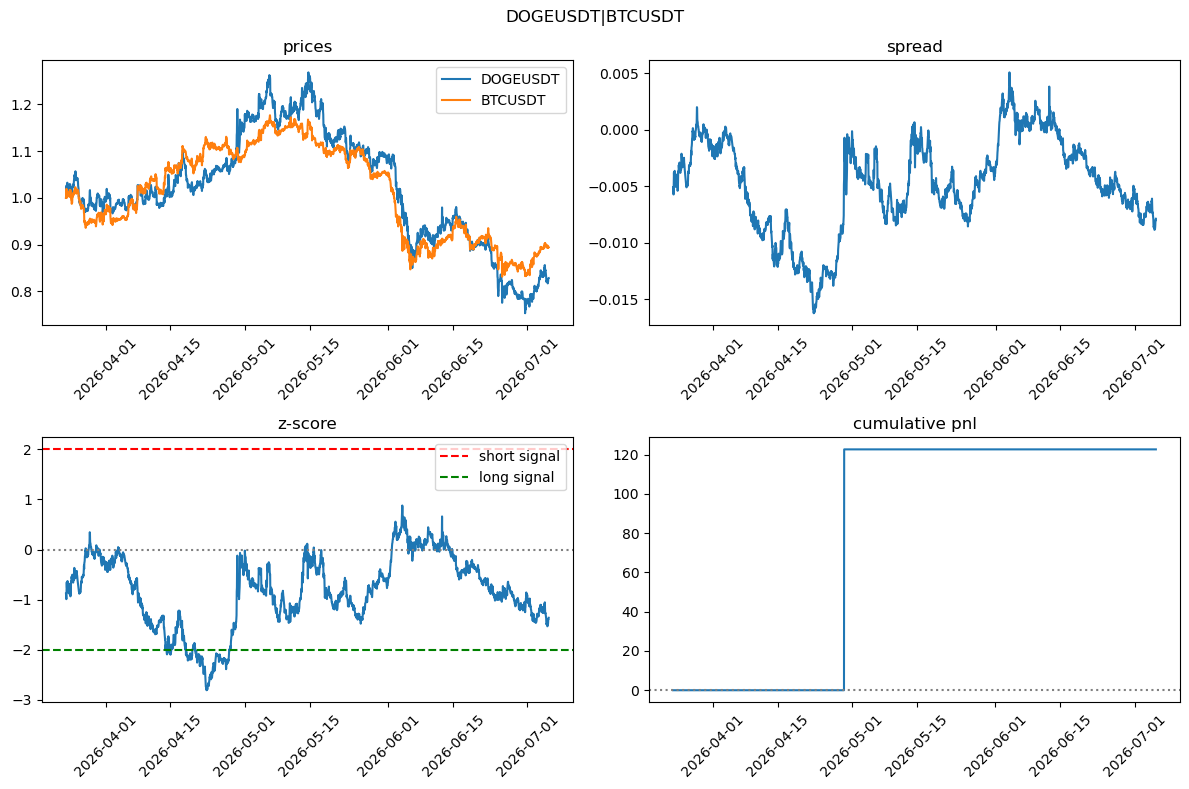

USDCUSDT|XRPUSDT
cointegration p-value (train): 0.0216
total pnl: $-189.26 over 104 days
daily pnl: $-1.82/day


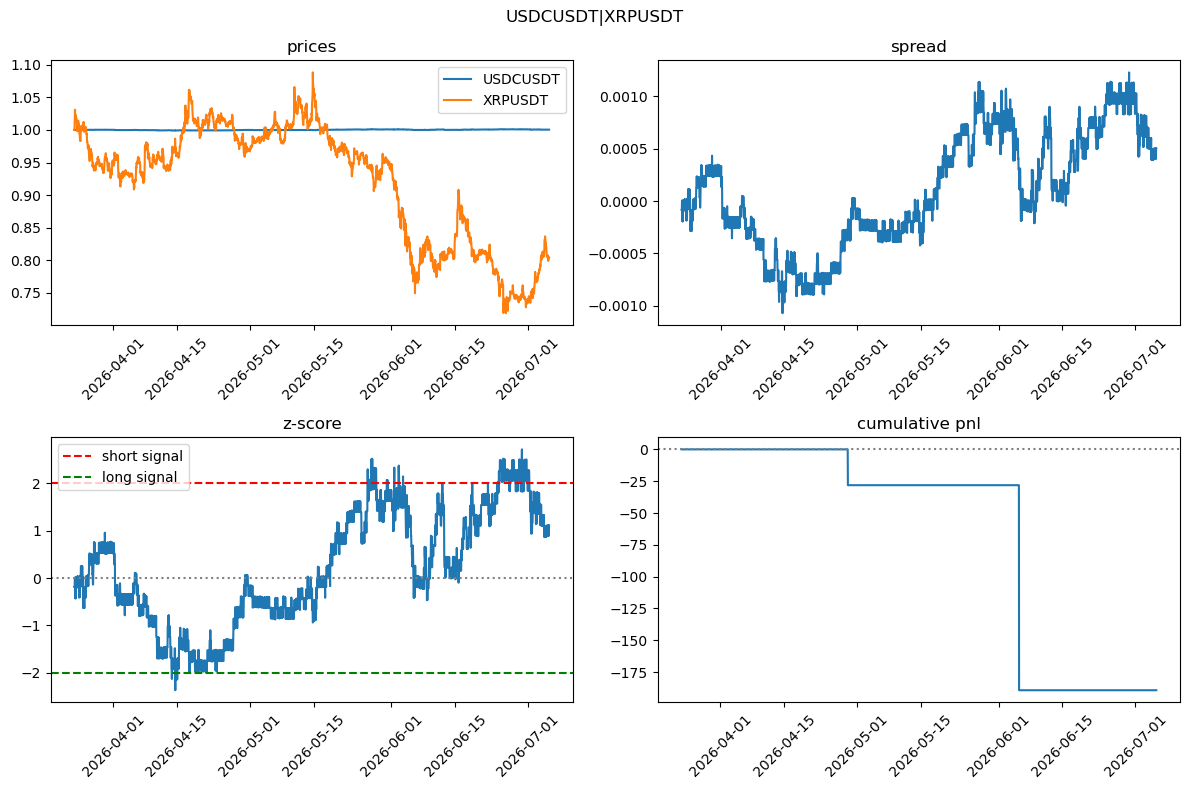

USDCUSDT|LITUSDT
insufficient data for USDCUSDT|LITUSDT
USDCUSDT|XPLUSDT
cointegration p-value (train): 0.0368
total pnl: $176.99 over 104 days
daily pnl: $1.70/day


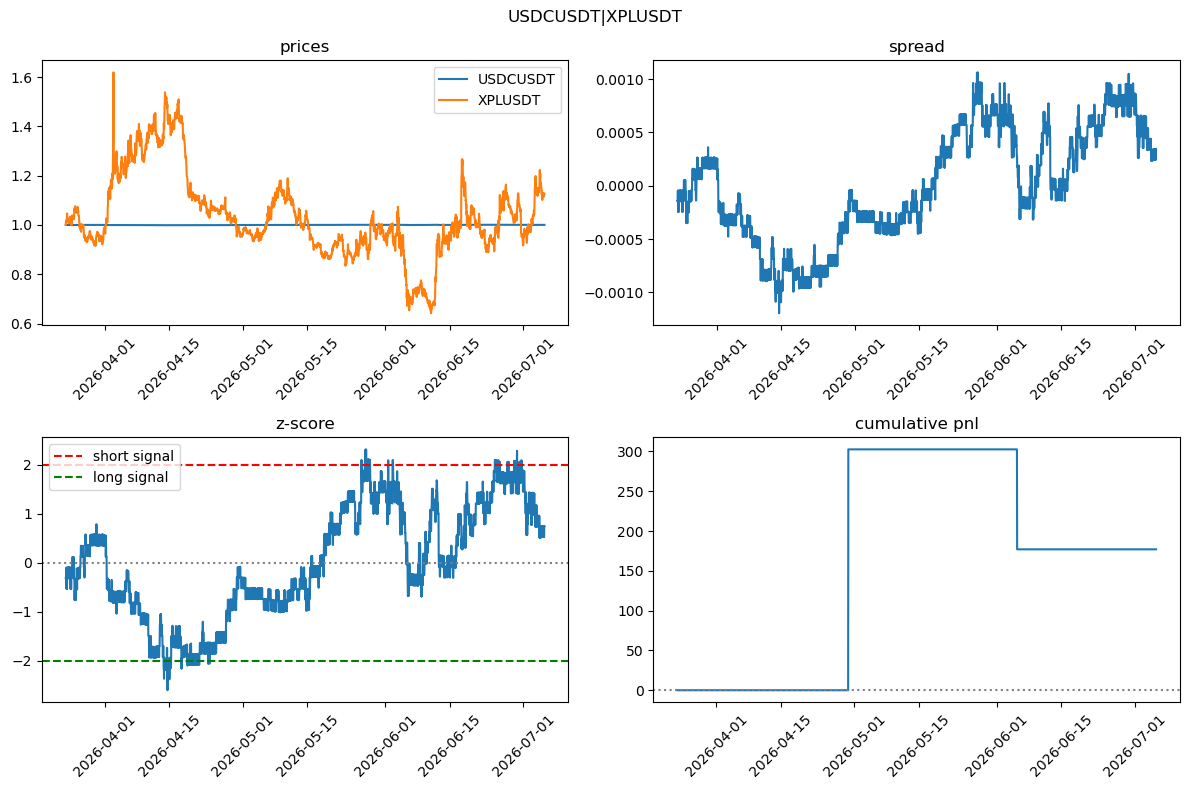

USDCUSDT|ETHUSDT
cointegration p-value (train): 0.0252
total pnl: $-223.08 over 104 days
daily pnl: $-2.14/day


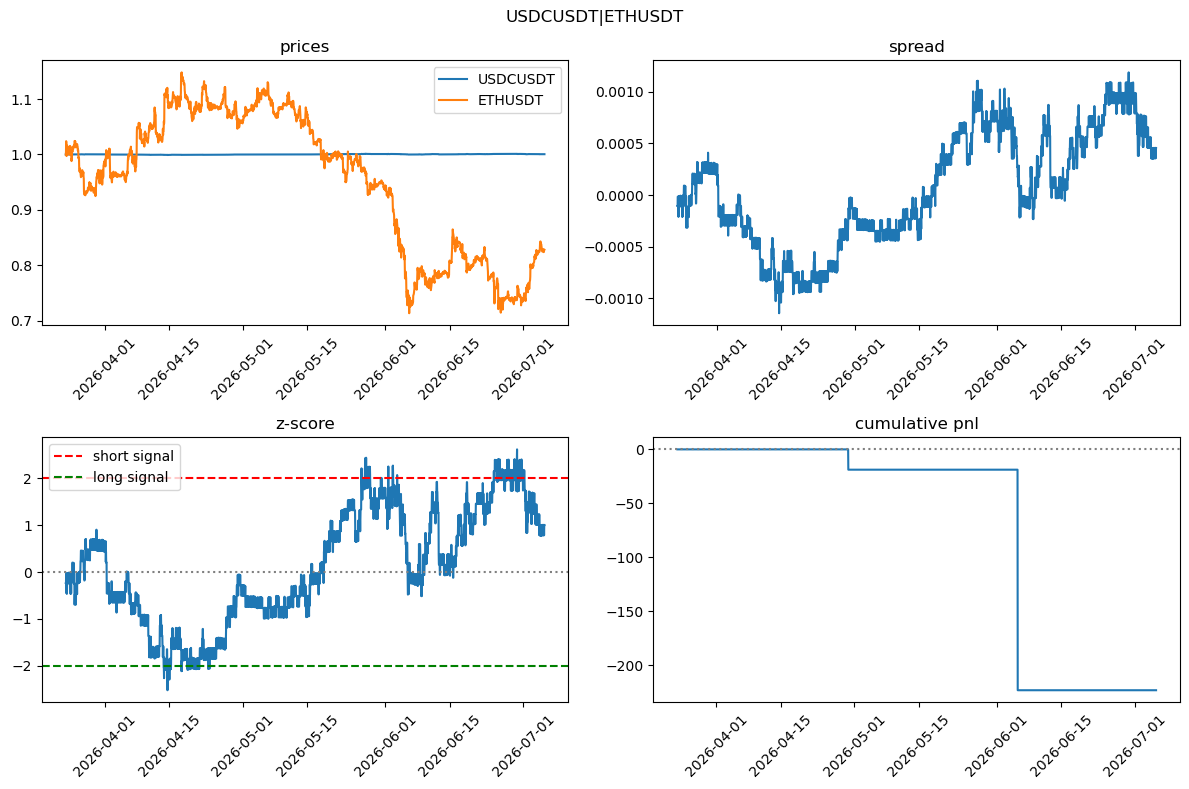

USDCUSDT|XLMUSDT
cointegration p-value (train): 0.0292
total pnl: $739.73 over 104 days
daily pnl: $7.11/day


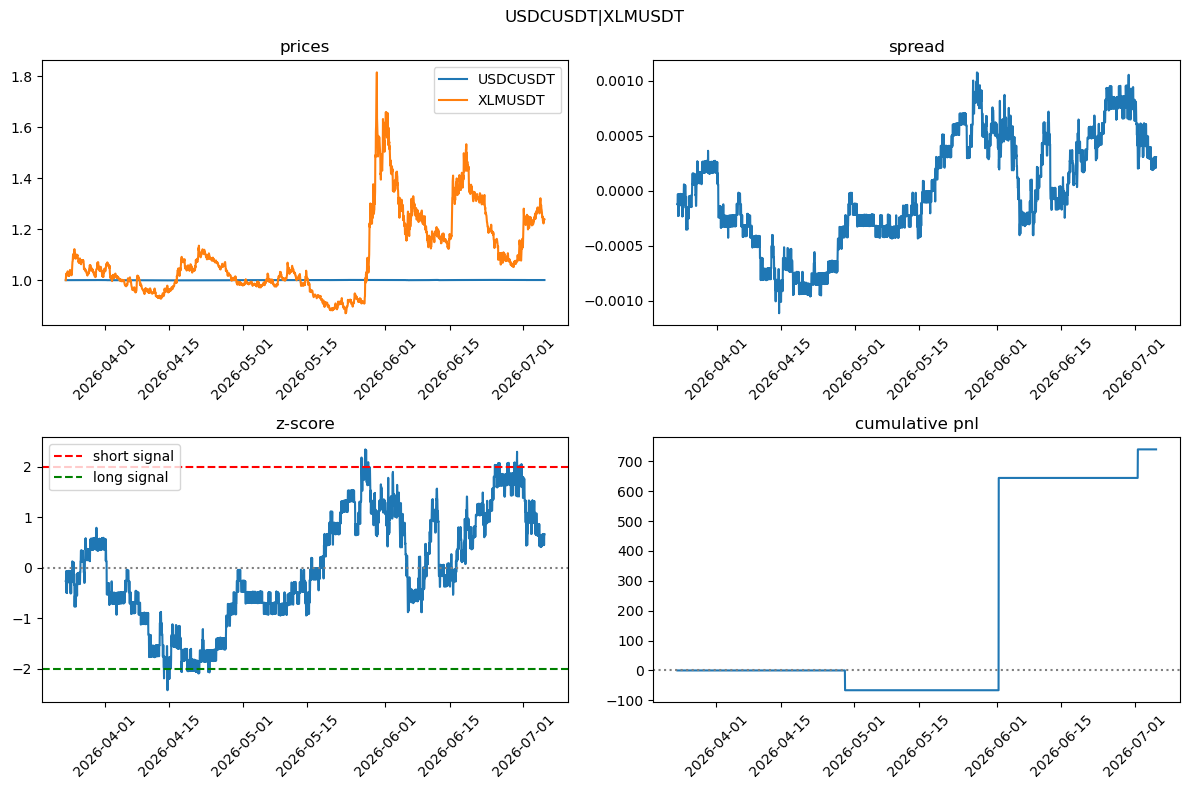

CAPUSDT|XRPUSDT
insufficient data for CAPUSDT|XRPUSDT
CAPUSDT|SLXUSDT
insufficient data for CAPUSDT|SLXUSDT
CAPUSDT|XPLUSDT
insufficient data for CAPUSDT|XPLUSDT
CAPUSDT|ETHUSDT
insufficient data for CAPUSDT|ETHUSDT
CAPUSDT|XLMUSDT
insufficient data for CAPUSDT|XLMUSDT
XRPUSDT|ETHUSDT
cointegration p-value (train): 0.0081
total pnl: $132.59 over 104 days
daily pnl: $1.27/day


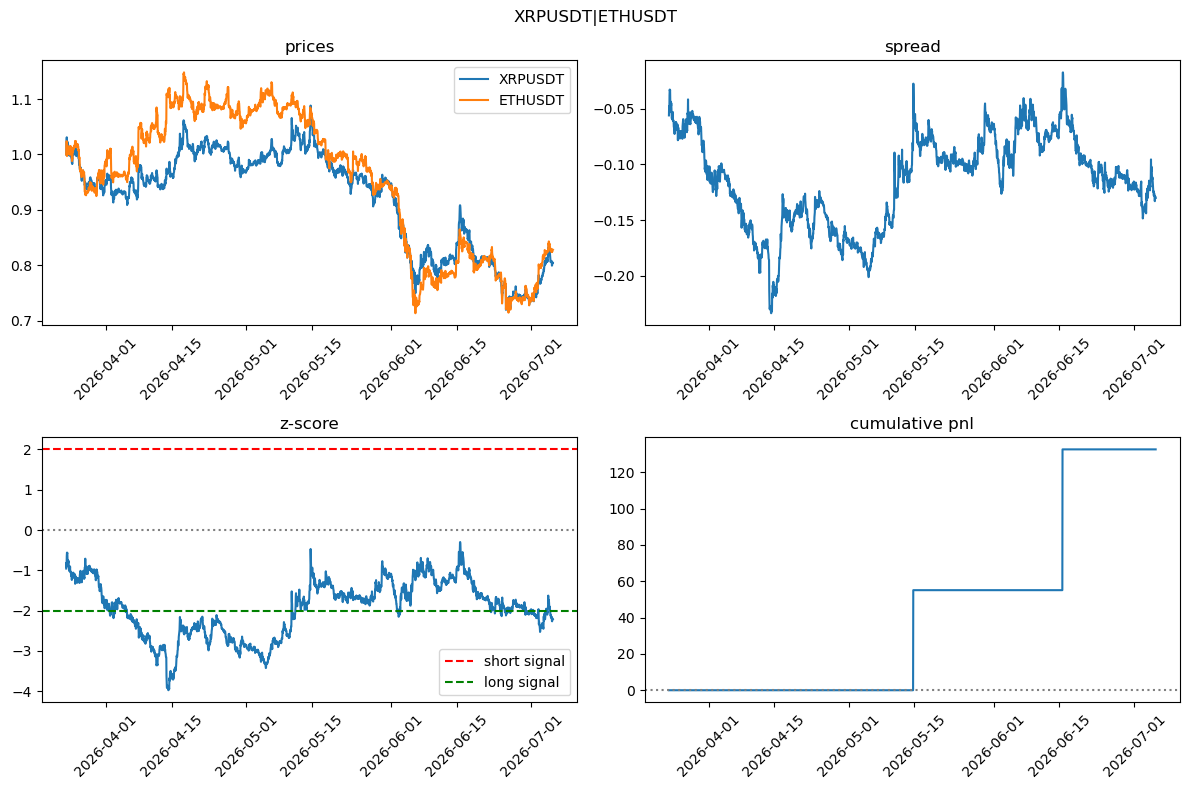

LITUSDT|SLXUSDT
insufficient data for LITUSDT|SLXUSDT


In [14]:
for ticker_a, ticker_b in zip(strong['ticker_a'], strong['ticker_b']):
    print(f"{ticker_a}|{ticker_b}")
    analyse_pair(ticker_a, ticker_b, data_liquid)